# Evolutionary Design Optimization of an Aircraft Configuration

A multi-objective optimization problem for the conceptual design of an aircraft using evolutionary algorithms. The aim is to generate aircraft configurations that reduce aerodynamic drag, provide sufficient fuel volume inside the wings, and maximize cargo capacity.

## 1. Problem Statement

The objective is to design an aircraft configuration using evolutionary algorithms. Each candidate solution represents a possible aircraft geometry described by a vector of design variables.

The aircraft should be optimized with respect to three main criteria:

1. Minimize aerodynamic drag.
2. Maximize the available fuel volume inside the wings.
3. Maximize the available cargo space.

These criteria are conflicting. For example, reducing drag may require thinner wings, but thinner wings reduce the internal fuel volume. Increasing cargo capacity may require a larger fuselage, but a larger fuselage may increase drag. The optimizer must therefore search for compromise solutions rather than a single perfect solution.

## 2. Design Variable Vector

Let the aircraft design be represented by the vector:

$$
x = \left[ b, S_w, AR, \Lambda, t_c, L_f, D_f, V_c, V_f, S_t, x_e \right]
$$

where:

- $b$ is the wing span;
- $S_w$ is the wing area;
- $AR$ is the wing aspect ratio;
- $\Lambda$ is the wing sweep angle;
- $t_c$ is the wing thickness-to-chord ratio;
- $L_f$ is the fuselage length;
- $D_f$ is the fuselage diameter;
- $V_c$ is the available cargo volume;
- $V_f$ is the fuel volume stored inside the wings;
- $S_t$ is the tail surface area;
- $x_e$ is the engine placement variable.

A simplified relation for the aspect ratio is:

$$
AR = \frac{b^2}{S_w}
$$

This relation can either be imposed as a constraint or used to compute $AR$ directly from $b$ and $S_w$.

In [ ]:
%%sql


## 3. Objective Functions

The aircraft design problem is formulated as a multi-objective optimization problem.

The first objective is to minimize the drag coefficient:

$$
\min f_1(x) = C_D(x)
$$

The second objective is to maximize the fuel volume inside the wings:

$$
\max f_2(x) = V_{fuel}(x)
$$

The third objective is to maximize the available cargo volume:

$$
\max f_3(x) = V_{cargo}(x)
$$

Since many evolutionary algorithms are formulated as minimization algorithms, the problem can be written as:

$$
\min F(x) = \left[ C_D(x), -V_{fuel}(x), -V_{cargo}(x) \right]
$$

where:

- $C_D(x)$ is the aerodynamic drag coefficient;
- $V_{fuel}(x)$ is the fuel volume stored inside the wings;
- $V_{cargo}(x)$ is the available cargo space.

## 4. Simplified Aerodynamic Model

A simplified drag model may be used during conceptual design:

$$
C_D(x) = C_{D0}(x) + C_{Di}(x)
$$

where $C_{D0}(x)$ is the zero-lift drag coefficient and $C_{Di}(x)$ is the induced drag coefficient.

The induced drag coefficient may be approximated as:

$$
C_{Di}(x) = \frac{C_L^2}{\pi e AR}
$$

where $C_L$ is the lift coefficient, $e$ is the Oswald efficiency factor, and $AR$ is the wing aspect ratio.

The lift coefficient can be approximated by:

$$
C_L = \frac{2W}{\rho V^2 S_w}
$$

where $W$ is the aircraft weight, $\rho$ is the air density, $V$ is the flight velocity, and $S_w$ is the wing area.

The drag force may be estimated as:

$$
D(x) = \frac{1}{2}\rho V^2 S_w C_D(x)
$$

## 5. Fuel Volume Model

The fuel volume stored in the wings depends on the wing geometry and the internal usable volume. A simplified approximation is:

$$
V_{fuel}(x) = k_f S_w \bar{c} t_c
$$

where $k_f$ is a fuel-volume efficiency coefficient, $S_w$ is the wing area, $\bar{c}$ is the mean aerodynamic chord, and $t_c$ is the wing thickness-to-chord ratio.

The mean aerodynamic chord may be approximated as:

$$
\bar{c} = \frac{S_w}{b}
$$

Therefore:

$$
V_{fuel}(x) = k_f S_w \left( \frac{S_w}{b} \right) t_c
$$

## 6. Cargo Volume Model

The cargo volume is mainly influenced by the fuselage geometry. A simplified model is:

$$
V_{cargo}(x) = k_c L_f D_f^2
$$

where $k_c$ is a cargo-space efficiency coefficient, $L_f$ is the fuselage length, and $D_f$ is the fuselage diameter.

A larger fuselage may increase cargo space, but it may also increase aerodynamic drag and structural weight.

## 7. Constraints

The aircraft design must satisfy aerodynamic, structural, stability, and capacity constraints.

### 7.1 Lift Constraint

The generated lift must be at least equal to the aircraft weight:

$$
L(x) \geq W(x)
$$

where:

$$
L(x) = \frac{1}{2}\rho V^2 S_w C_L
$$

### 7.2 Minimum Fuel Capacity

$$
V_{fuel}(x) \geq V_{fuel}^{min}
$$

### 7.3 Minimum Cargo Capacity

$$
V_{cargo}(x) \geq V_{cargo}^{min}
$$

### 7.4 Structural Constraint

$$
\sigma(x) \leq \sigma_{max}
$$

### 7.5 Wing Area Bounds

$$
S_w^{min} \leq S_w(x) \leq S_w^{max}
$$

### 7.6 Aspect Ratio Bounds

$$
AR^{min} \leq AR(x) \leq AR^{max}
$$

### 7.7 Stability Constraint

$$
SM(x) \geq SM_{min}
$$

where $SM(x)$ is the static margin.

## 8. Evolutionary Algorithm Formulation

An evolutionary algorithm can be used to solve this constrained multi-objective problem. Suitable algorithms include Genetic Algorithm, NSGA-II, Differential Evolution, Multi-Objective Particle Swarm Optimization, and Evolution Strategies.

Each individual in the population represents an aircraft design:

$$
P = \{x_1, x_2, \ldots, x_N\}
$$

where $N$ is the population size.

Each individual is evaluated using the objective vector:

$$
F(x_i) = \left[ C_D(x_i), -V_{fuel}(x_i), -V_{cargo}(x_i) \right]
$$

The evolutionary algorithm applies selection, crossover, mutation, and replacement operators in order to evolve better aircraft designs over multiple generations.

## 9. Constraint Handling

Constraints can be handled using a penalty function. The penalized objective can be written as:

$$
F_p(x) = F(x) + \lambda P(x)
$$

where $F_p(x)$ is the penalized objective vector, $F(x)$ is the original objective vector, $\lambda$ is a penalty coefficient, and $P(x)$ is the total constraint violation.

A possible total penalty function is:

$$
P(x) = \sum_{j=1}^{m} \max(0, g_j(x))^2
$$

where $g_j(x) \leq 0$ represents the $j$-th inequality constraint.

## 10. Pareto Optimality

Because the problem has multiple conflicting objectives, the final output should not be a single design, but a set of Pareto-optimal aircraft configurations.

A design $x_a$ dominates another design $x_b$ if:

$$
f_i(x_a) \leq f_i(x_b), \quad \forall i
$$

and:

$$
\exists j \text{ such that } f_j(x_a) < f_j(x_b)
$$

The set of non-dominated solutions forms the Pareto front:

$$
PF = \{x \in X \mid \nexists y \in X : y \prec x\}
$$

where $y \prec x$ means that $y$ dominates $x$.

### Explanation of Pareto optimality

In a multi-objective optimization problem, several objectives must be optimized at the same time. 
Since these objectives may conflict with each other, there is usually no single solution that is optimal 
for all objectives simultaneously.

Let a solution be represented by a vector of decision variables:

$$\mathbf{x} = (x_1, x_2, \ldots, x_n) \in \Omega,$$


where $\Omega$ is the feasible search space. The objective function is defined as:

$$\mathbf{f}(\mathbf{x}) = \left(f_1(\mathbf{x}), f_2(\mathbf{x}), \ldots, f_m(\mathbf{x})\right),$$


where $m$ is the number of objectives.

Assuming a minimization problem, a solution $\mathbf{x}^{(1)}$ is said to dominate another solution 
$\mathbf{x}^{(2)}$, written as:

$$\mathbf{x}^{(1)} \prec \mathbf{x}^{(2)},$$

if the following two conditions are satisfied:

$$f_i(\mathbf{x}^{(1)}) \leq f_i(\mathbf{x}^{(2)}), \quad \forall i \in \{1,2,\ldots,m\},$$


and

$$\exists j \in \{1,2,\ldots,m\} \text{ such that } f_j(\mathbf{x}^{(1)}) < f_j(\mathbf{x}^{(2)}).$$


In other words, $\mathbf{x}^{(1)}$ is at least as good as $\mathbf{x}^{(2)}$ in all objectives and strictly 
better in at least one objective.

A solution $\mathbf{x}^*$ is called Pareto optimal if there is no other feasible solution 
$\mathbf{x} \in \Omega$ that dominates it:

$$\nexists \mathbf{x} \in \Omega \text{ such that } \mathbf{x} \prec \mathbf{x}^*.$$


The set of all Pareto optimal solutions is called the Pareto set:

$$P^* = \left\{ \mathbf{x}^* \in \Omega \mid \nexists \mathbf{x} \in \Omega : \mathbf{x} \prec \mathbf{x}^* \right\}.$$


The image of the Pareto set in the objective space is called the Pareto front:

$$PF^* = \left\{ \mathbf{f}(\mathbf{x}^*) \mid \mathbf{x}^* \in P^* \right\}.$$

In the aircraft design problem, the Pareto front contains aircraft designs that represent different 
trade-offs between objectives such as minimizing drag, minimizing fuel volume in the wings, and 
maximizing cargo space. A design on the Pareto front cannot be improved in one objective without 
worsening at least one other objective.

## 11. Generic Evolutionary Algorithm Procedure

The evolutionary optimization process can be summarized as follows:

1. Initialize a population of aircraft designs.
2. Evaluate aerodynamic drag, fuel volume, and cargo volume for each design.
3. Check constraints and apply penalties if necessary.
4. Select the best individuals based on Pareto dominance and diversity.
5. Apply crossover to generate new aircraft designs.
6. Apply mutation to introduce geometric variation.
7. Replace part or all of the population with the new individuals.
8. Repeat the process until a stopping criterion is met.
9. Return the Pareto-optimal set of aircraft designs.

The stopping criterion may be:

$$
t \geq T_{max}
$$

or:

$$
\Delta PF \leq \varepsilon
$$

where $t$ is the current generation, $T_{max}$ is the maximum number of generations, $\Delta PF$ is the change in the Pareto front, and $\varepsilon$ is a convergence threshold.

## 12. Example Python Skeleton

The following code provides a minimal structure for evaluating candidate aircraft designs. This is not a full aerodynamic solver. It is a simplified conceptual model intended for optimization experiments.

In [1]:
from idlelib.rpc import objecttable

import numpy as np

# Constants used in the simplified model
rho = 1.225          # air density at sea level [kg/m^3]
V = 230.0            # cruise speed [m/s]
e = 0.8              # Oswald efficiency factor
W = 7.0e5            # aircraft weight [N]
k_f = 0.45           # fuel volume efficiency coefficient
k_c = 0.60           # cargo volume efficiency coefficient

# Minimum requirements
V_fuel_min = 80.0    # minimum fuel volume [m^3]
V_cargo_min = 120.0  # minimum cargo volume [m^3]
AR_min = 6.0
AR_max = 14.0
S_w_min = 80.0
S_w_max = 300.0

In [3]:
def ex_evaluate_aircraft(x):
    """
    Evaluate a simplified aircraft design.
    Design vector: x = [b, S_w, sweep, t_c, L_f, D_f]
    """
    b, S_w, sweep, t_c, L_f, D_f = x
    AR = b**2 / S_w
    C_L = 2 * W / (rho * V**2 * S_w)
    C_D0 = 0.018 + 0.002 * (D_f / L_f) + 0.0001 * abs(sweep)
    C_Di = C_L**2 / (np.pi * e * AR)
    C_D = C_D0 + C_Di
    c_bar = S_w / b
    V_fuel = k_f * S_w * c_bar * t_c
    V_cargo = k_c * L_f * D_f**2
    return C_D, V_fuel, V_cargo, AR

In [4]:
def ex_constraint_penalty(x):
    """Compute a simple penalty for constraint violations."""
    C_D, V_fuel, V_cargo, AR = ex_evaluate_aircraft(x)
    b, S_w, sweep, t_c, L_f, D_f = x
    violations = [
        max(0, V_fuel_min - V_fuel),
        max(0, V_cargo_min - V_cargo),
        max(0, AR_min - AR),
        max(0, AR - AR_max),
        max(0, S_w_min - S_w),
        max(0, S_w - S_w_max),
    ]
    return sum(v**2 for v in violations)

In [5]:
def ex_objective_function(x, penalty_weight=1e3):
    """
    Multi-objective function converted into a penalized vector.
    Objectives: minimize drag, maximize fuel volume, maximize cargo volume.
    """
    C_D, V_fuel, V_cargo, AR = ex_evaluate_aircraft(x)
    penalty = ex_constraint_penalty(x)
    return np.array([
        C_D + penalty_weight * penalty,
        -V_fuel + penalty_weight * penalty,
        -V_cargo + penalty_weight * penalty,
    ])

In [6]:
# Example candidate aircraft design
# x = [wing span, wing area, sweep angle, thickness-to-chord ratio, fuselage length, fuselage diameter]
x_example = np.array([42.0, 140.0, 25.0, 0.12, 38.0, 4.5])

C_D, V_fuel, V_cargo, AR = ex_evaluate_aircraft(x_example)
F = ex_objective_function(x_example)

print("Example aircraft design:")
print(f"Drag coefficient C_D: {C_D:.5f}")
print(f"Fuel volume: {V_fuel:.2f} m^3")
print(f"Cargo volume: {V_cargo:.2f} m^3")
print(f"Aspect ratio: {AR:.2f}")
print(f"Objective vector: {F}")

Example aircraft design:
Drag coefficient C_D: 0.02149
Fuel volume: 25.20 m^3
Cargo volume: 461.70 m^3
Aspect ratio: 12.60
Objective vector: [3003040.02148882 3003014.8        3002578.3       ]


## 13. Final Problem Formulation

The complete problem can be stated as follows:

Design an aircraft configuration using evolutionary algorithms in order to minimize aerodynamic drag, maximize the fuel volume stored in the wings, and maximize the available cargo space. The problem is treated as a constrained multi-objective optimization task, where each candidate solution represents a complete aircraft geometry.

The final optimization problem is:

$$
\min F(x) = \left[ C_D(x), -V_{fuel}(x), -V_{cargo}(x) \right]
$$

subject to:

$$
L(x) \geq W(x)
$$

$$
V_{fuel}(x) \geq V_{fuel}^{min}
$$

$$
V_{cargo}(x) \geq V_{cargo}^{min}
$$

$$
\sigma(x) \leq \sigma_{max}
$$

$$
S_w^{min} \leq S_w(x) \leq S_w^{max}
$$

$$
AR^{min} \leq AR(x) \leq AR^{max}
$$

$$
SM(x) \geq SM_{min}
$$

The evolutionary algorithm should return a Pareto front of feasible aircraft designs, allowing the designer to choose an appropriate compromise between aerodynamic efficiency, fuel capacity, and cargo space.

In [13]:
# my choice of algorithm is NSGA-II
# I used the problem constants defined above by the teacher

import math
import random
import matplotlib.pyplot as plt
import numpy as np

# Constants used in the simplified model
rho = 1.225  # air density at sea level [kg/m^3]
V = 230.0  # cruise speed [m/s]
e = 0.8  # Oswald efficiency factor
W = 7.0e5  # aircraft weight [N]
k_f = 0.45  # fuel volume efficiency coefficient
k_c = 0.60  # cargo volume efficiency coefficient

# Minimum requirements
V_fuel_min = 80.0  # minimum fuel volume [m^3]
V_cargo_min = 120.0  # minimum cargo volume [m^3]
AR_min = 6.0
AR_max = 14.0
S_w_min = 80.0
S_w_max = 300.0

In [14]:
BOUNDS = np.array([
    [20.0, 70.0], # b: wing span [m]
    [80.0, 300.0], # S_w: wing area [m^2]
    [0.0,  45.0], # sweep: wing sweep angle [deg]
    [0.08, 0.18], # t_c: thickness-to-chord ratio
    [25.0, 65.0], # L_f: fuselage length [m]
    [3.0,  7.0], # D_f: fuselage diameter [m]
])

N_VARS = len(BOUNDS)

In [15]:
def evaluate_aircraft(x):
    """
    Evaluate a simplified aircraft design.
    Design vector: x = [b, S_w, sweep, t_c, L_f, D_f]
    """
    b, S_w, sweep, t_c, L_f, D_f = x
    AR = b**2 / S_w
    C_L = 2 * W / (rho * V**2 * S_w)
    C_D0 = 0.018 + 0.002 * (D_f / L_f) + 0.0001 * abs(sweep)
    C_Di = C_L**2 / (np.pi * e * AR)
    C_D = C_D0 + C_Di

    c_bar = S_w / b
    V_fuel = k_f * S_w * c_bar * t_c
    V_cargo = k_c * L_f * D_f**2

    return C_D, V_fuel, V_cargo, AR

In [16]:
def constraint_penalty(x):
    """Compute a simple penalty for constraint violations."""
    C_D, V_fuel, V_cargo, AR = evaluate_aircraft(x)
    b, S_w, sweep, t_c, L_f, D_f = x
    violations = [
        max(0, V_fuel_min - V_fuel), # minimum fuel volume
        max(0, V_cargo_min - V_cargo),  # minimum cargo volume
        max(0, AR_min - AR), # aspect ratio lower bound
        max(0, AR - AR_max), # aspect ratio upper bound
        max(0, S_w_min - S_w), # wing area lower bound
        max(0, S_w - S_w_max), # wing area upper bound
    ]
    return sum(v**2 for v in violations)

def objective_function(x, penalty_weight=1e3):
    """
    Multi-objective penalized fitness.
    Minimise: [C_D, -V_fuel, -V_cargo]  (all minimisation)
    """
    C_D, V_fuel, V_cargo, AR = evaluate_aircraft(x)
    penalty = constraint_penalty(x)
    return np.array([
        C_D + penalty_weight* penalty,
        -V_fuel + penalty_weight * penalty,
        -V_cargo + penalty_weight * penalty,
    ])

In [17]:
#population initialization: let the hunger games begin

def random_individual():
    """Creates a random aircraft design within variable bounds."""
    return [random.uniform(lo, hi) for lo, hi in BOUNDS]

def initialize_population(pop_size):
    """Population of random aircraft designs."""
    return [random_individual() for _ in range(pop_size)]

In [18]:
# using the NSGA-II algorithm

def dominates(obj_a, obj_b):
    """True if solution a dominates solution b (minimisation)."""
    return np.all(obj_a <= obj_b) and np.any(obj_a < obj_b)

def fast_non_dominated_sort(obj_values):
    """
    Fast non-dominated sorting
    Returns: (fronts, rank) where fronts[0] is the Pareto front.
    Time: O(M N^2), M = num objectives, N = pop size.
    """
    n = len(obj_values)
    rank = np.zeros(n, dtype=int)
    dominated_set = [[] for _ in range(n)]
    dominated_by_count = np.zeros(n, dtype=int)
    fronts = [[]]

    for i in range(n):
        for j in range(n):
            if i == j: continue
            if dominates(obj_values[i], obj_values[j]):
                dominated_set[i].append(j)
            elif dominates(obj_values[j], obj_values[i]):
                dominated_by_count[i] += 1
        if dominated_by_count[i] == 0:
            rank[i] = 0
            fronts[0].append(i)

    k = 0
    while fronts[k]:
        next_front = []
        for i in fronts[k]:
            for j in dominated_set[i]:
                dominated_by_count[j] -= 1
                if dominated_by_count[j] == 0:
                    rank[j] = k + 1
                    next_front.append(j)
        k += 1
        fronts.append(next_front)

    return fronts[:-1], rank

def crowding_distance(obj_values, front):
    """
    Crowding distance for solutions in a single front.
    Boundary solutions get distance = inf.
    Higher distance = more isolated = better diversity contribution.
    """
    if len(front) <= 2:
        return {i: np.inf for i in front}

    distances = {i: 0.0 for i in front}
    n_obj = obj_values.shape[1]

    for m in range(n_obj):
        vals = sorted([(obj_values[i, m], i) for i in front])
        distances[vals[0][1]] = np.inf
        distances[vals[-1][1]] = np.inf
        obj_range = vals[-1][0] - vals[0][0]
        if obj_range == 0:
            continue
        for k in range(1, len(vals) - 1):
            distances[vals[k][1]] += (vals[k+1][0] - vals[k-1][0]) / obj_range

    return distances

In [19]:
#selection

def tournament_selection(population, ranks, crowding, k=2):
    """
    Binary tournament selection based on rank and crowding distance.
    Lower rank is better. Ties broken by higher crowding distance.
    """
    candidates = random.sample(range(len(population)), k)
    best = candidates[0]
    for c in candidates[1:]:
        if ranks[c] < ranks[best]:
            best = c
        elif ranks[c] == ranks[best] and crowding[c] > crowding[best]:
            best = c
    return population[best][:]

In [20]:
#crossover

def uniform_crossover(parent1, parent2, crossover_rate=0.9):
    """Each gene comes from parent1 or parent2 with equal probability."""
    if random.random() > crossover_rate:
        return parent1[:], parent2[:]
    child1, child2 = [], []
    for g1, g2 in zip(parent1, parent2):
        if random.random() < 0.5:
            child1.append(g1); child2.append(g2)
        else:
            child1.append(g2); child2.append(g1)
    return child1, child2

In [21]:
#mutation

def gaussian_mutation(individual, mutation_rate=0.15, sigma=0.1):
    """
    Adds Gaussian noise to each gene with probability mutation_rate.
    Sigma is expressed as a fraction of the variable range.
    """
    mutated = individual[:]
    for i in range(N_VARS):
        if random.random() < mutation_rate:
            scale = (BOUNDS[i, 1] - BOUNDS[i, 0]) * sigma
            mutated[i] += random.gauss(0, scale)
            mutated[i]  = max(BOUNDS[i, 0], min(BOUNDS[i, 1], mutated[i]))  # clip to bounds
    return mutated

In [22]:
# example for these newly added functions
p1 = random_individual()
p2 = random_individual()
c1, c2 = uniform_crossover(p1, p2)
m1 = gaussian_mutation(c1)

print("Parent 1:", [f"{v:.2f}" for v in p1])
print("Parent 2:", [f"{v:.2f}" for v in p2])
print("Child 1:", [f"{v:.2f}" for v in c1])
print("Mutated:", [f"{v:.2f}" for v in m1])

Parent 1: ['62.30', '196.90', '2.81', '0.15', '33.97', '4.64']
Parent 2: ['52.38', '261.14', '27.50', '0.13', '64.65', '6.94']
Child 1: ['52.38', '196.90', '2.81', '0.13', '64.65', '4.64']
Mutated: ['49.02', '196.90', '2.81', '0.13', '65.00', '4.64']


In [23]:
def build_ranks_and_crowding(population):
    """Helper: evaluate population, sort, and return ranks + crowding dists."""
    obj_vals = np.array([objective_function(x) for x in population])
    fronts, _ = fast_non_dominated_sort(obj_vals)
    rank_list = [0] * len(population)
    crowd_list = [0.0] * len(population)
    for rank, front in enumerate(fronts):
        cd = crowding_distance(obj_vals, front)
        for idx in front:
            rank_list[idx] = rank
            crowd_list[idx] = cd[idx]
    return obj_vals, fronts, rank_list, crowd_list

def run_nsga2(pop_size=100, max_generations=150,
              crossover_rate=0.9, mutation_rate=0.15, sigma=0.1,
              seed=42, verbose=True):
    """
    Returns: pareto_pop, pareto_obj, history_pareto_size, history_best_cd
    """
    random.seed(seed)
    np.random.seed(seed)

    population = initialize_population(pop_size)
    history_pareto_size = []
    history_best_cd = []

    if verbose:
        print(f"{'Gen':>5}  {'Pareto size':>12}  {'Best C_D':>10}")
        print("-" * 35)

    for generation in range(max_generations):
        obj_vals, fronts, rank_list, crowd_list = build_ranks_and_crowding(population)

        offspring = []
        while len(offspring) < pop_size:
            p1 = tournament_selection(population, rank_list, crowd_list)
            p2 = tournament_selection(population, rank_list, crowd_list)
            c1, c2 = uniform_crossover(p1, p2, crossover_rate)
            c1 = gaussian_mutation(c1, mutation_rate, sigma)
            c2 = gaussian_mutation(c2, mutation_rate, sigma)
            offspring.append(c1)
            if len(offspring) < pop_size:
                offspring.append(c2)

        combined = population + offspring
        obj_combined = np.array([objective_function(x) for x in combined])
        fronts_c, _ = fast_non_dominated_sort(obj_combined)
        rank_c = [0] * len(combined)
        crowd_c = [0.0] * len(combined)

        for rank, front in enumerate(fronts_c):
            cd = crowding_distance(obj_combined, front)
            for idx in front:
                rank_c[idx] = rank
                crowd_c[idx] = cd[idx]

        next_gen_idx = []
        for front in fronts_c:
            if len(next_gen_idx) + len(front) <= pop_size:
                next_gen_idx.extend(front)
            else:
                remaining = pop_size - len(next_gen_idx)
                sorted_front = sorted(front, key=lambda i: crowd_c[i], reverse=True)
                next_gen_idx.extend(sorted_front[:remaining])
                break

        population = [combined[i] for i in next_gen_idx]
        pareto_size = len(fronts_c[0])
        best_cd = min(obj_combined[i][0] for i in fronts_c[0])
        history_pareto_size.append(pareto_size)
        history_best_cd.append(float(best_cd))

        if verbose and (generation % 30 == 0 or generation == max_generations - 1):
            print(f"{generation:>5}  {pareto_size:>12}  {best_cd:>10.5f}")

    final_obj = np.array([objective_function(x) for x in population])
    final_fronts, _ = fast_non_dominated_sort(final_obj)
    pareto_idx = final_fronts[0]
    pareto_pop = [population[i] for i in pareto_idx]
    pareto_obj = [final_obj[i].tolist() for i in pareto_idx]

    return pareto_pop, pareto_obj, history_pareto_size, history_best_cd

In [24]:
pareto_pop, pareto_obj, history, cd_hist = run_nsga2(
    pop_size = 100,
    max_generations = 150,
    crossover_rate = 0.9,
    mutation_rate = 0.15,
    sigma = 0.1,
    seed = 42,
    verbose = True,
)

print(f"\nOptimization is (cross)over.")
print(f"Pareto front size: {len(pareto_pop)} designs")

# extract raw objective values (unpenalised)
C_D_vals = [o[0] for o in pareto_obj]
V_fuel_vals = [-o[1] for o in pareto_obj]
V_cargo_vals = [-o[2] for o in pareto_obj]

# feasibility check
feasible = [constraint_penalty(x) == 0 for x in pareto_pop]
print(f"Feasible designs: {sum(feasible)} / {len(pareto_pop)}  ({100*sum(feasible)/len(pareto_pop):.1f}%)")

  Gen   Pareto size    Best C_D
-----------------------------------
    0             6     0.01925
   30           163     0.01824
   60           164     0.01824
   90           158     0.01824
  120           158     0.01824
  149           164     0.01824

Optimization is (cross)over.
Pareto front size: 100 designs
Feasible designs: 93 / 100  (93.0%)


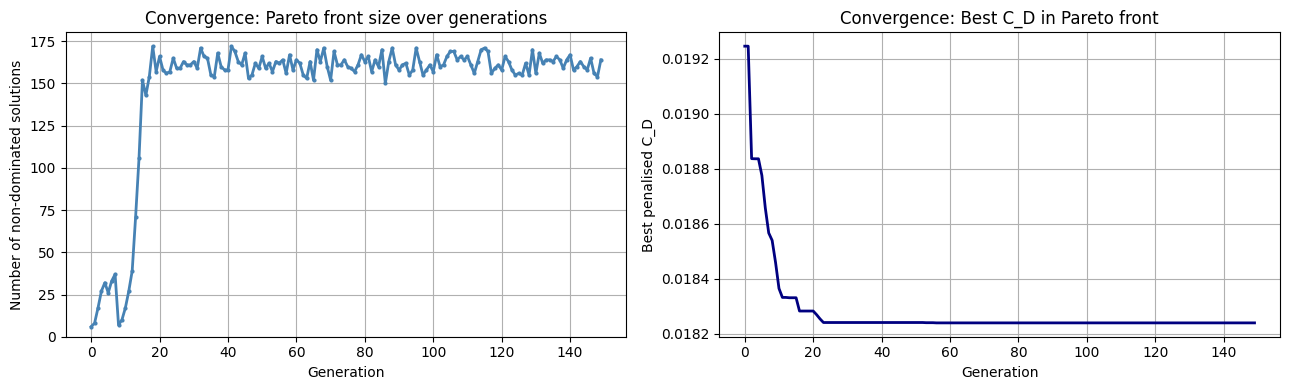

In [25]:
# the convergence plot

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(history, color='steelblue', linewidth=2, marker='o', markersize=2)
ax1.set_xlabel("Generation")
ax1.set_ylabel("Number of non-dominated solutions")
ax1.set_title("Convergence: Pareto front size over generations")
ax1.set_ylim(bottom=0)
ax1.grid(True)

ax2.plot(cd_hist, color='navy', linewidth=2)
ax2.set_xlabel("Generation")
ax2.set_ylabel("Best penalised C_D")
ax2.set_title("Convergence: Best C_D in Pareto front")
ax2.grid(True)

plt.tight_layout()
plt.show()

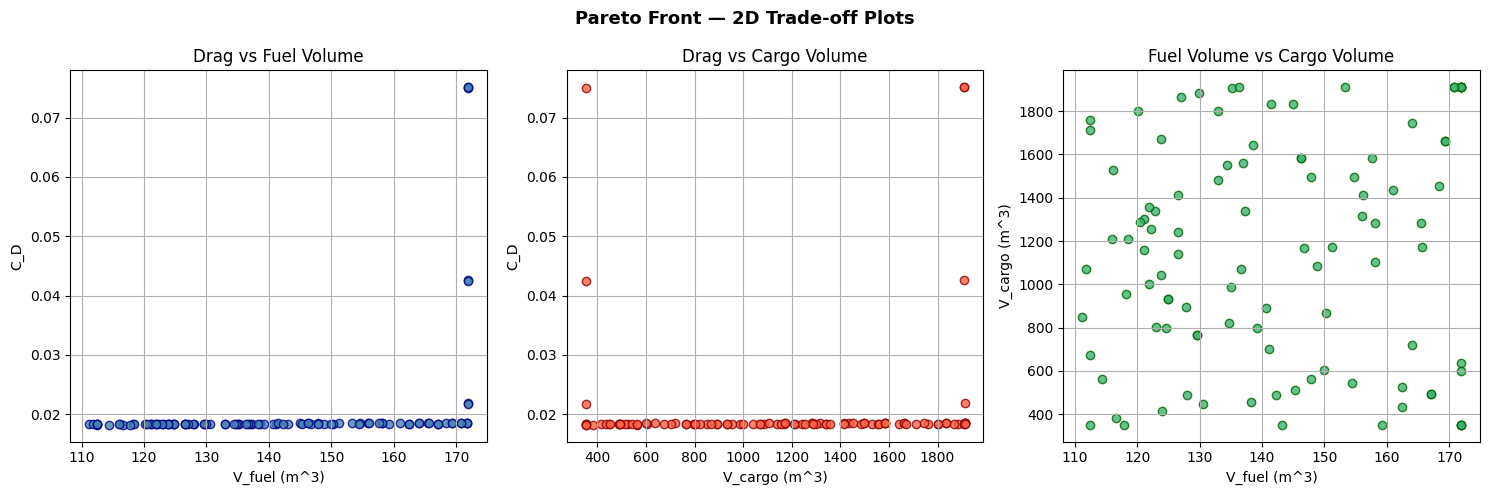

In [26]:
# the 2d tradeoff

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].scatter(V_fuel_vals, C_D_vals, color='steelblue', edgecolors='navy', alpha=0.8)
axes[0].set_xlabel("V_fuel (m^3)")
axes[0].set_ylabel("C_D")
axes[0].set_title("Drag vs Fuel Volume")
axes[0].grid(True)

axes[1].scatter(V_cargo_vals, C_D_vals, color='tomato', edgecolors='darkred', alpha=0.8)
axes[1].set_xlabel("V_cargo (m^3)")
axes[1].set_ylabel("C_D")
axes[1].set_title("Drag vs Cargo Volume")
axes[1].grid(True)

axes[2].scatter(V_fuel_vals, V_cargo_vals, color='mediumseagreen', edgecolors='darkgreen', alpha=0.8)
axes[2].set_xlabel("V_fuel (m^3)")
axes[2].set_ylabel("V_cargo (m^3)")
axes[2].set_title("Fuel Volume vs Cargo Volume")
axes[2].grid(True)

plt.suptitle("Pareto Front — 2D Trade-off Plots", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

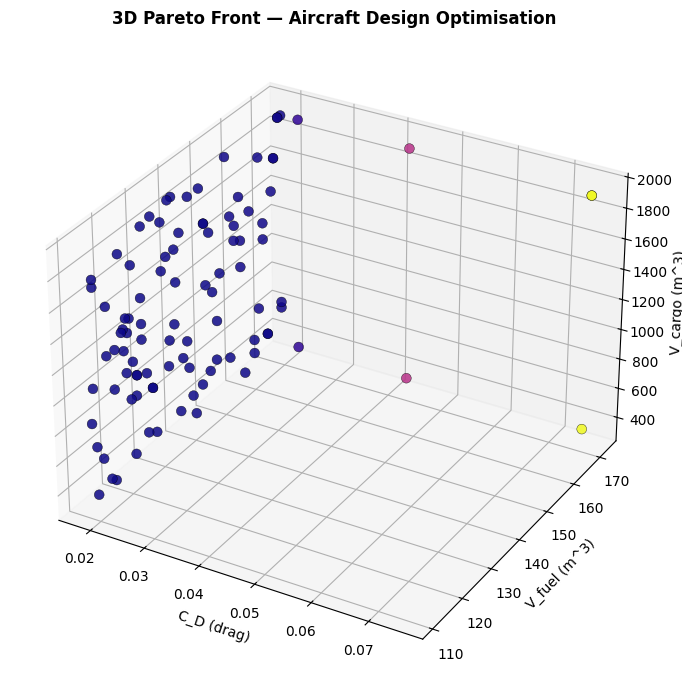

In [27]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(9, 7))
ax  = fig.add_subplot(111, projection='3d')

ax.scatter(C_D_vals, V_fuel_vals, V_cargo_vals,
           c=C_D_vals, cmap='plasma', s=50, edgecolors='k', linewidths=0.3, alpha=0.85)

ax.set_xlabel("C_D (drag)")
ax.set_ylabel("V_fuel (m^3)")
ax.set_zlabel("V_cargo (m^3)")
ax.set_title("3D Pareto Front — Aircraft Design Optimisation", fontweight='bold')
plt.tight_layout()
plt.show()

In [36]:
 # table to highlight the difference between low drag, high cargo, and the best compromise

cd_arr = np.array(C_D_vals)
vf_arr = np.array(V_fuel_vals)
vc_arr = np.array(V_cargo_vals)

idx_low_drag = int(np.argmin(cd_arr))
idx_high_cargo = int(np.argmax(vc_arr))
idx_high_fuel = int(np.argmax(vf_arr))

def normalise(arr):
    r = arr.max() - arr.min()
    return (arr - arr.min()) / r if r > 0 else np.zeros_like(arr)

norm_cd = normalise(cd_arr)
norm_vf = normalise(-vf_arr)
norm_vc = normalise(-vc_arr)
dist_utopia = np.sqrt(norm_cd**2 + norm_vf**2 + norm_vc**2)
idx_compromise = int(np.argmin(dist_utopia))

var_names = ["b (m)", "S_w (m^2)", "sweep (deg)", "t_c", "L_f (m)", "D_f (m)"]
labels = {
    "Low Drag": idx_low_drag,
    "High Fuel": idx_high_fuel,
    "High Cargo": idx_high_cargo,
    "Best Compromise": idx_compromise,
}

col_w = 13
header = f"{'Design':<18}" + "".join(f"{n:>{col_w}}" for n in var_names + ["C_D", "V_fuel(m^3)", "V_cargo(m^3)"])
print("=" * len(header))
print("CANDIDATE DESIGN TABLE")
print("=" * len(header))
print(header)
print("-" * len(header))

for name, idx in labels.items():
    x = pareto_pop[idx]
    obj = pareto_obj[idx]
    vals = list(x) + [obj[0], -obj[1], -obj[2]]
    print(f"{name:<18}" + "".join(f"{v:>{col_w}.4f}" for v in vals))

print("=" * len(header))

CANDIDATE DESIGN TABLE
Design                    b (m)    S_w (m^2)  sweep (deg)          t_c      L_f (m)      D_f (m)          C_D  V_fuel(m^3) V_cargo(m^3)
---------------------------------------------------------------------------------------------------------------------------------------
Low Drag                64.8061     300.0000       0.0000       0.1800      65.0000       3.0000       0.0182     112.4894     351.0000
High Fuel               42.3998     300.0000       0.0000       0.1800      65.0000       7.0000       0.0751     171.8782    1910.9434
High Cargo              42.6862     300.0000       0.0000       0.1800      65.0000       7.0000       0.0186     170.7812    1911.0000
Best Compromise         42.4353     300.0000       0.0000       0.1800      65.0000       7.0000       0.0186     171.7908    1911.0000


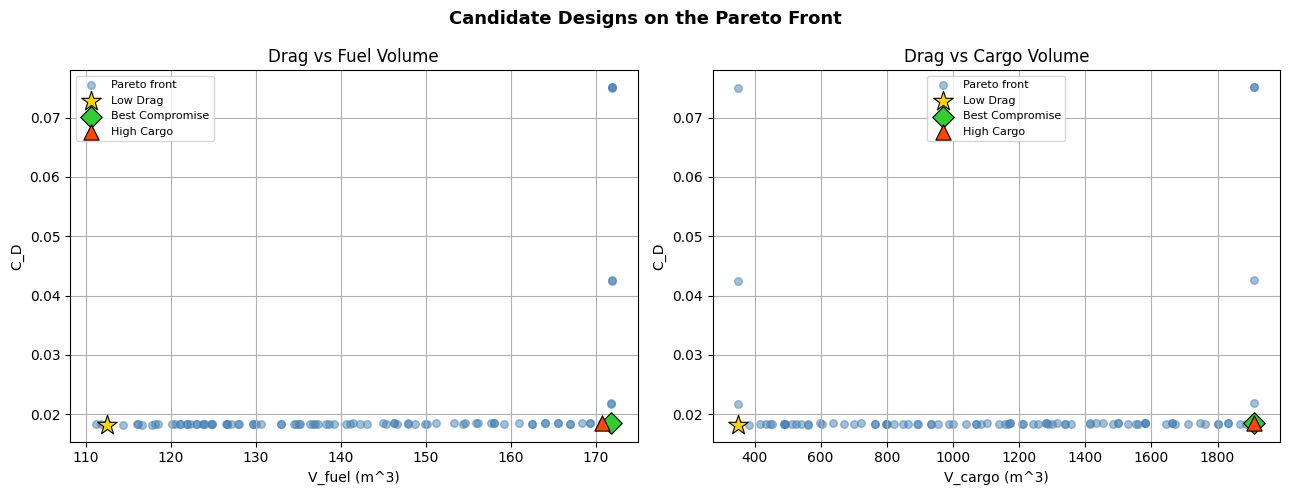

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

highlight = {
    "Low Drag": (idx_low_drag, 'gold', '*', 220),
    "Best Compromise": (idx_compromise, 'limegreen', 'D', 120),
    "High Cargo": (idx_high_cargo, 'orangered', '^', 120),
}

for ax, (xdata, ydata, xlabel, ylabel, title) in zip(axes, [
    (V_fuel_vals,  C_D_vals, "V_fuel (m^3)",  "C_D", "Drag vs Fuel Volume"),
    (V_cargo_vals, C_D_vals, "V_cargo (m^3)", "C_D", "Drag vs Cargo Volume"),
]):
    ax.scatter(xdata, ydata, color='steelblue', alpha=0.5, s=30, label='Pareto front')
    for label, (idx, color, marker, size) in highlight.items():
        ax.scatter(xdata[idx], ydata[idx], color=color, marker=marker,
                   s=size, zorder=5, label=label, edgecolors='black', linewidths=0.8)
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); ax.set_title(title)
    ax.legend(fontsize=8); ax.grid(True)

plt.suptitle("Candidate Designs on the Pareto Front", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

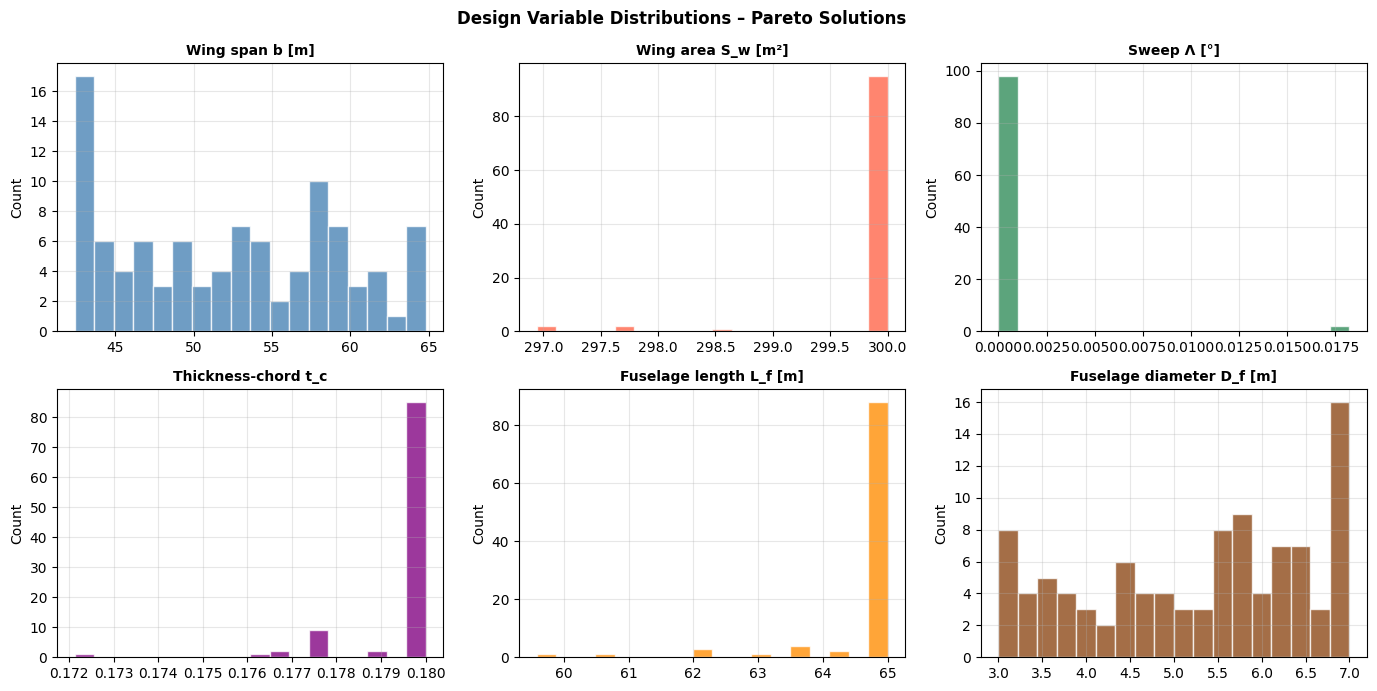

In [31]:
labels_v = ['Wing span b [m]', 'Wing area S_w [m²]', 'Sweep Λ [°]',
            'Thickness-chord t_c', 'Fuselage length L_f [m]', 'Fuselage diameter D_f [m]']
colors_v = ['steelblue', 'tomato', 'seagreen', 'purple', 'darkorange', 'saddlebrown']
pop_arr  = np.array(pareto_pop)

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    ax.hist(pop_arr[:, i], bins=18, color=colors_v[i], alpha=0.78, edgecolor='white')
    ax.set_title(labels_v[i], fontsize=10, fontweight='bold')
    ax.set_ylabel('Count'); ax.grid(True, alpha=0.3)

plt.suptitle('Design Variable Distributions – Pareto Solutions', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()